# Learn better rotations
In our last experiment, our model was able to learn/predict rotations to some degree. But it wasn't doing great. The learning was slow, and there was still a lot of error after +1000 epochs. Let's see if we can find a better representation and loss function for our rotations.

## Load Data

In [1]:
%load_ext autoreload
%autoreload 2

import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)
# Choose device (cuda if available, else cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

2.9.0+cu128
Selected device: cuda


In [2]:
## Load the colmap data
import pycolmap
import pathlib
import utils.subset
import random
import utils.loaders

# Load the Colmap data into a torch dataset
model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762043798762/0')
reconstruction = pycolmap.Reconstruction(model_path)

## Generate Data

In [67]:
import numpy as np
from scipy.spatial.transform import Rotation

# Define the directory where our source images are from
image_dir = pathlib.Path('data', '01_nerf', '02_lego_large')

# Create a random subset using distance based heuristic
random.seed(42)
# a_ids, b_ids = utils.subset.create_image_subsets_from_distance(reconstruction, 15, random_captains=True)
INCLUDE_IMAGE_FEATURES = True

graph_a_list = []
graph_b_list = []
labels_translations = []
labels_quat_xyzw = []
for i in range(100):
    a_ids, b_ids = utils.subset.create_image_subsets_from_distance(reconstruction, 15, random_captains=True)
    # Create a PyG graph Dataset for each subset
    graph_a = utils.loaders.load_reconstruction_to_graph_sfm(reconstruction, image_dir, a_ids, include_image_features=INCLUDE_IMAGE_FEATURES)
    graph_b = utils.loaders.load_reconstruction_to_graph_sfm(reconstruction, image_dir, b_ids, include_image_features=INCLUDE_IMAGE_FEATURES)
    # 1. Generate a random translation. We uniformly sample 3 values from the range [-10.0, 10.0]
    # random_translation = torch.empty(3).uniform_(-10.0,10.0) # TODO temp commented out
    random_translation = torch.tensor([0,0,0]).float()
    # 1. Generate random rotation
    random_rotation = Rotation.random().as_quat()
    # random_rotation = np.array([0.0, 0.0, 0.0, 1.0])  # TODO temporary test...
    # 2. Create Rigid3D to make math easy
    random_transform = pycolmap.Rigid3d(random_rotation, random_translation)
    # 3. Apply the rotation/translation to the Rigid3d
    graph_b.rigid3d = [random_transform * rigid for rigid in graph_b.rigid3d]
    # 4. Update the node features with the updated values
    graph_b_pos = np.stack([rigid.translation for rigid in graph_b.rigid3d], axis=0) # np.stack just converts form a list to an array. nothing fancy.
    graph_b_pos = torch.from_numpy(graph_b_pos).float()
    graph_b_rot = np.stack([rigid.rotation.quat for rigid in graph_b.rigid3d], axis=0)
    graph_b_rot = torch.from_numpy(graph_b_rot).float()
    # Concatenate the translation, rotation, and image features into one long feature vector for each node
    if INCLUDE_IMAGE_FEATURES: # TODO clean this up. this is messy!
        graph_b.x = torch.hstack([graph_b_pos, graph_b_rot, graph_b.image_features])
    else:
        graph_b.x = torch.hstack([graph_b_pos, graph_b_rot])
    graph_a_list.append(graph_a)
    graph_b_list.append(graph_b)
    labels_translations.append(random_translation)
    random_rotation_tensor = torch.from_numpy(np.stack(random_rotation)).float()
    labels_quat_xyzw.append(random_rotation_tensor)

# Data Loader

In [68]:
from utils.loaders.dataset import SfmPairDataset
from utils.loaders import GraphPairDataset

# Create the Dataset
dataset = SfmPairDataset(graph_a_list, graph_b_list, labels_translations, labels_quat_xyzw)
dataset

SfmPairDataset(100)

In [81]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

# Split our dataset based on 80-20 training-validation split
dataset_size = len(dataset)
train_size = int(dataset_size * 0.8)
val_size = dataset_size - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# And we create a distinct DataLoader for each dataset train and val
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Training Loop

In [82]:
from utils.loss import quaternion_loss
from datetime import datetime
## Train
import numpy as np
from models import SiameseGCN_v2
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(43)
random.seed(43)

GRAPH_EMBEDDING_SIZE = 8

# Define model
num_node_features = dataset.g_list_1[0].num_features
model = SiameseGCN_v2(num_node_features, graph_embedding_dim=GRAPH_EMBEDDING_SIZE)
model.to(device)

# optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=400, gamma=0.8)
criterion_translation = torch.nn.MSELoss()
criterion_rotation = torch.nn.MSELoss() # TODO this is bad! this won't work with quaternions!
# criterion_rotation = quaternion_loss

NUM_EPOCHS = 1600
LAMBDA_1 = 0.1 # weight for translation v rotation loss

# View results by running in the terminal:
# tensorboard --logdir=runs/x20_learn_rotations
timestamp_str = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter(f'runs/x21_better_rotation_emb{GRAPH_EMBEDDING_SIZE}/{timestamp_str}')

# Keep track of loss for logging
epoch_losses_train = []
epoch_losses_val = np.full(NUM_EPOCHS, np.nan)  # one slot per epoch. makes plotting easier
with tqdm(range(NUM_EPOCHS),desc=f"Training progress") as pbar:
    for epoch in pbar:
        model.train()
        train_loss_all = 0.0
        train_loss_translation = 0.0
        train_loss_rotation = 0.0
        for batch in train_loader:
            # Move data to the GPU
            graph_a_batch         = batch[0].to(device)
            graph_b_batch         = batch[1].to(device)
            labels_translations   = batch[2].to(device)
            labels_quat_xyzw      = batch[3].to(device)
            optimizer.zero_grad()
            pred_translation, pred_rotation = model(graph_a_batch, graph_b_batch)
            # loss = criterion(out, label_batch)
            # Calculate translation loss
            loss_trans = criterion_translation(pred_translation, labels_translations)
            # Calculate rotation loss
            loss_rotation = criterion_rotation(pred_rotation, labels_quat_xyzw)
            # loss_rotation = torch.tensor(0) # TODO Temp
            # Combine loss
            # TODO weight the various loss
            loss = LAMBDA_1*loss_trans + loss_rotation
            # Compute gradient
            loss.backward()
            # update the weights
            optimizer.step()
            train_loss_all += loss.item()
            train_loss_translation += loss_trans.item()
            train_loss_rotation += loss_rotation.item()
        avg_loss = train_loss_all / len(train_loader)
        avg_loss_translation = train_loss_translation / len(train_loader)
        avg_loss_rotation = train_loss_rotation / len(train_loader)
        writer.add_scalar('loss_all/train', avg_loss, epoch)
        writer.add_scalar('loss_translation/train', avg_loss_translation, epoch)
        writer.add_scalar('loss_rotation/train', avg_loss_rotation, epoch)
        epoch_losses_train.append(avg_loss)
        pbar.set_postfix({'loss': f'{avg_loss:.4f}', 'loss_trans': f'{avg_loss_translation:.4f}', 'loss_rot:': f'{avg_loss_rotation:.4f}' })
        # learning rate decay
        scheduler.step()

        # Validation
        if epoch % 10 == 0:
            model.eval()
            val_loss = 0.0
            val_loss_translation = 0.0
            val_loss_rotation = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    graph_a_batch = batch[0].to(device)
                    graph_b_batch = batch[1].to(device)
                    labels_translations   = batch[2].to(device)
                    labels_quat_xyzw   = batch[3].to(device)
                    pred_translation, pred_rotation = model(graph_a_batch, graph_b_batch)
                    # Calculate translation loss
                    loss_trans = criterion_translation(pred_translation, labels_translations)
                    # Calculate rotation loss
                    loss_rotation = criterion_rotation(pred_rotation, labels_quat_xyzw)
                    # loss_rotation = torch.tensor(0.0) #temp
                    # Combine loss
                    loss = LAMBDA_1*loss_trans + loss_rotation
                    val_loss += loss.item()
                    val_loss_translation += loss_trans.item()
                    val_loss_rotation += loss_rotation.item()
                avg_val_loss = val_loss / len(val_loader)
                avg_val_loss_translation = val_loss_translation / len(val_loader)
                avg_val_loss_rotation = val_loss_rotation / len(val_loader)
                epoch_losses_val[epoch] = avg_val_loss
                writer.add_scalar('loss_all/val', avg_val_loss, epoch)
                writer.add_scalar('loss_translation/val', avg_val_loss_translation, epoch)
                writer.add_scalar('loss_rotation/val', avg_val_loss_rotation, epoch)

Training progress: 100%|██████████| 1600/1600 [02:14<00:00, 11.87it/s, loss=0.0285, loss_trans=0.0000, loss_rot:=0.0285]


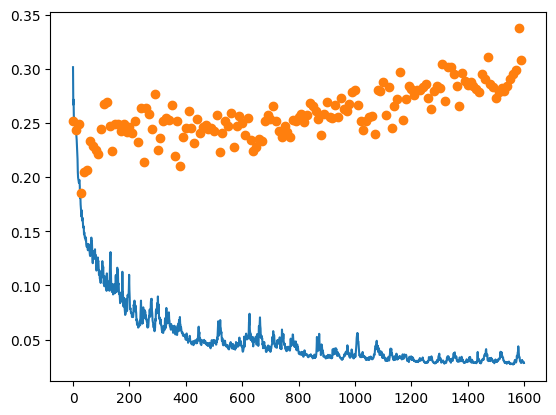

In [83]:
# Plot the results!
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epoch_losses_train)
plt.plot(epoch_losses_val, marker='o')
plt.show()

# Visualize Prediction

Here we visualize a prediction. This visual is for the training dataset. We notice it looks pretty good! But if we take a look at an example from the validation dataset... we will see that it fails to generalize.

In [93]:
import utils.vis

# Use the new helper function to visualize predictions
sample = train_dataset[5]
predicted_graph_b, true_graph_b, graph_a, graph_b = utils.vis.visualize_sfm_prediction(model, sample)

# Conclusion

The model is overfitting for rotation prediction - is not really learning anything generalizable to the validation dataset... I think there is something fundamentally wrong with the way we are setting up this rotation learning task!